# EEG Seizure Detection - Corrected Notebook

In [1]:
!pip install numpy matplotlib scikit-learn tensorflow


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Bidirectional, 
                                     LSTM, Dense, Dropout, Layer, GlobalAveragePooling1D)
from tensorflow.keras import regularizers


['train_signals', 'train_labels']
X shape: (37666, 23, 256)
Y shape: (37666,)
Label distribution: {np.int64(0): np.int64(29592), np.int64(1): np.int64(8074)}


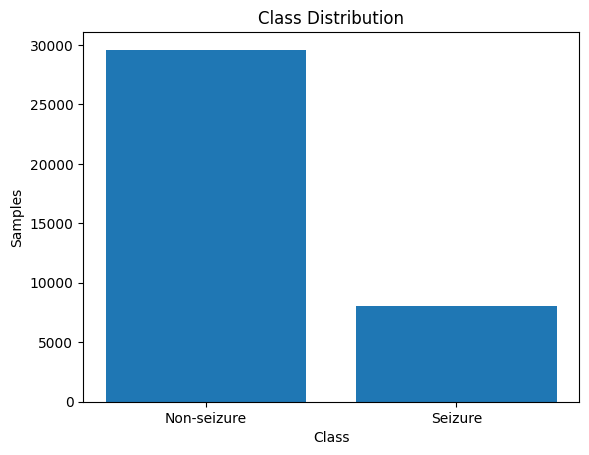

In [2]:
data = np.load('EEG dataset/eeg-seizure_train.npz')
print(data.files)

X = data['train_signals']
Y = data['train_labels']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

unique, counts = np.unique(Y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

plt.bar(['Non-seizure', 'Seizure'], counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.show()


In [3]:
X_mean = X.mean(axis=2, keepdims=True)
X_std = X.std(axis=2, keepdims=True)
X_std[X_std == 0] = 1  # Prevent division by zero

X_normalized = (X - X_mean) / X_std
print("X normalized shape:", X_normalized.shape)

X_lstm = np.transpose(X_normalized, (0, 2, 1))
print("X for LSTM shape:", X_lstm.shape)


X normalized shape: (37666, 23, 256)
X for LSTM shape: (37666, 256, 23)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_lstm, Y, test_size=0.2, random_state=42, stratify=Y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)


Train shape: (30132, 256, 23) (30132,)
Validation shape: (7534, 256, 23) (7534,)


In [5]:
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        alpha = tf.keras.backend.softmax(e, axis=1)
        context = inputs * alpha
        context = tf.keras.backend.sum(context, axis=1)
        return context


In [6]:
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

cnn = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(cnn)
cnn = MaxPooling1D(pool_size=2)(cnn)

lstm = Bidirectional(LSTM(64, return_sequences=True))(cnn)
lstm = Bidirectional(LSTM(32, return_sequences=True))(lstm)

attn = Attention()(lstm)

drop = Dropout(0.4)(attn)
dense = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(drop)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=input_layer, outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 23)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 256, 128)            │          14,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 128, 64)             │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 64, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 64, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64, 64)              │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention (Attention)                │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,105 (590.25 KB)

 Trainable params: 151,105 (590.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,   
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 61s 56ms/step - accuracy: 0.8082 - loss: 0.7323 - val_accuracy: 0.8529 - val_loss: 0.3488
Epoch 2/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.8771 - loss: 0.3103 - val_accuracy: 0.9030 - val_loss: 0.2515
Epoch 3/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 80s 56ms/step - accuracy: 0.8981 - loss: 0.2607 - val_accuracy: 0.9103 - val_loss: 0.2315
Epoch 4/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 84s 58ms/step - accuracy: 0.9123 - loss: 0.2285 - val_accuracy: 0.9085 - val_loss: 0.2233
Epoch 5/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9148 - loss: 0.2219 - val_accuracy: 0.9131 - val_loss: 0.2201
Epoch 6/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.9264 - loss: 0.1940 - val_accuracy: 0.9185 - val_loss: 0.2095
Epoch 7/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.9300 - loss: 0.1907 - val_accuracy: 0.9116 - val_loss: 0.2344
Epoch 8/40
942/942 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9389 - loss: 0.1701 - 

In [9]:
loss, acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {acc:.4f}")


236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9242 - loss: 0.1969
Validation Accuracy: 0.9245


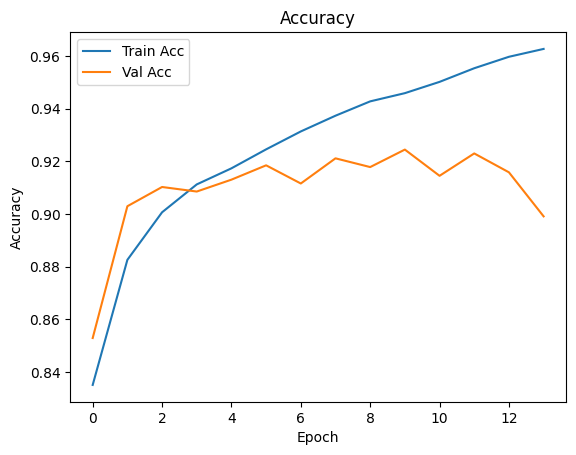

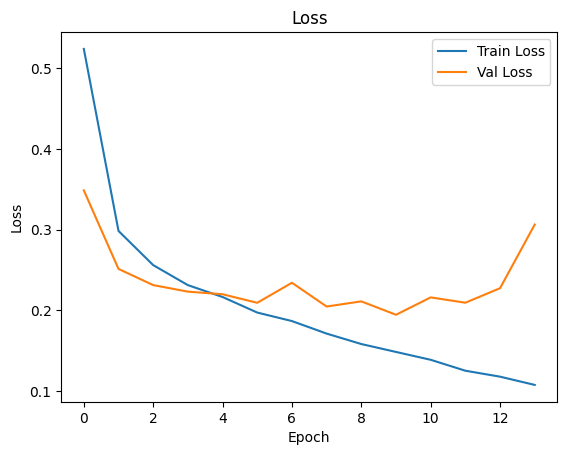

In [10]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [12]:
model.save('seizure_model.keras')
print("Model Saved ✅")

Model Saved ✅


In [13]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)

print("Data Saved ✅")

Data Saved ✅
